In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import scipy.io as sio
from torch.utils.data import Dataset, DataLoader, random_split


input_data = sio.loadmat('input_file500_50hDS.mat')
output_data = sio.loadmat('output_file500_50hDS.mat')

x1 = input_data['x1']   # (N, 2000, 1000)
x2 = input_data['x2']
Y  = output_data['Y']   # (N, 4)

print("Shapes:", x1.shape, x2.shape, Y.shape)


Shapes: (500, 2000, 1000) (500, 2000, 1000) (500, 4)


In [6]:
# =================== Preprocessing ================
# Log scaling
x1 = np.log1p(x1)
x2 = np.log1p(x2)

# Normalize each sample
def normalize(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-6)

x1 = np.array([normalize(s) for s in x1])
x2 = np.array([normalize(s) for s in x2])

# Normalize output (VERY IMPORTANT)
Y = Y.astype(np.float32)

Y[:, 0:2] /= 1000.0   # position scaling
Y[:, 2:4] /= 100.0    # velocity scaling


In [7]:
# ===================== Datset =============
class RadarDataset(Dataset):
    def __init__(self, x1, x2, Y):
        self.x = np.stack([x1, x2], axis=1)  # (N, 2, H, W)
        self.y = Y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return torch.tensor(self.x[idx], dtype=torch.float32), \
               torch.tensor(self.y[idx], dtype=torch.float32)

dataset = RadarDataset(x1, x2, Y)

In [8]:
# =============== Train and split ============

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=4)

In [9]:
# =========== CNN model ===========
class RadarCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(2, 8, 3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, 3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d((4, 4))
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.fc(self.conv(x))


In [10]:
# =============== Training steup =========
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = RadarCNN().to(device)

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)


In [11]:
# ============= Training looping + Loss tracking =============
train_losses = []
val_losses = []

epochs = 25

for epoch in range(epochs):

    # ---------- TRAIN ----------
    model.train()
    train_loss = 0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        pred = model(x_batch)
        loss = criterion(pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # ---------- VALIDATION ----------
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x_batch, y_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            pred = model(x_batch)
            val_loss += criterion(pred, y_batch).item()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")


Epoch 01 | Train: 3.3256 | Val: 0.5610
Epoch 02 | Train: 2.2514 | Val: 0.4151
Epoch 03 | Train: 1.7524 | Val: 0.9002
Epoch 04 | Train: 1.4230 | Val: 2.7728
Epoch 05 | Train: 1.5012 | Val: 0.7125
Epoch 06 | Train: 1.2029 | Val: 0.1874
Epoch 07 | Train: 1.1180 | Val: 1.0982
Epoch 08 | Train: 1.1105 | Val: 0.8397
Epoch 09 | Train: 0.9963 | Val: 0.3683
Epoch 10 | Train: 0.9747 | Val: 0.0828
Epoch 11 | Train: 0.9491 | Val: 0.0880
Epoch 12 | Train: 1.0297 | Val: 0.6475
Epoch 13 | Train: 0.8707 | Val: 0.1170
Epoch 14 | Train: 0.7797 | Val: 0.1812
Epoch 15 | Train: 0.7337 | Val: 0.0895
Epoch 16 | Train: 0.7125 | Val: 0.0728
Epoch 17 | Train: 0.7539 | Val: 0.2078
Epoch 18 | Train: 0.6653 | Val: 0.0793
Epoch 19 | Train: 0.5876 | Val: 0.0790
Epoch 20 | Train: 0.7039 | Val: 0.0893
Epoch 21 | Train: 0.6321 | Val: 0.0979
Epoch 22 | Train: 0.5725 | Val: 0.0720
Epoch 23 | Train: 0.7048 | Val: 0.2771
Epoch 24 | Train: 0.5379 | Val: 0.0612
Epoch 25 | Train: 0.5392 | Val: 0.0950


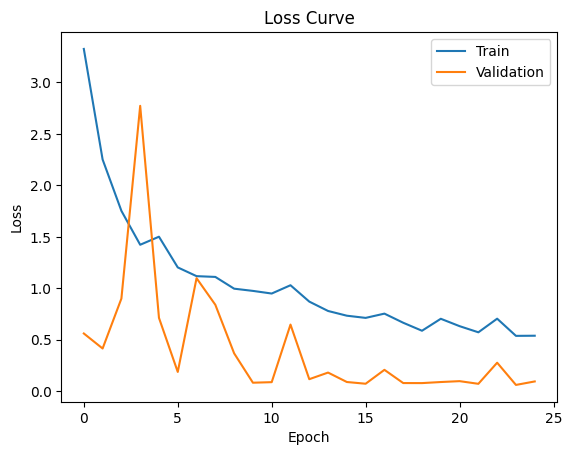

In [13]:
# =========== los curve plot ============
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Validation")
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [14]:
# ================= test prediction=============
model.eval()

for i in range(5):
    x_sample, y_true = dataset[i]

    with torch.no_grad():
        pred = model(x_sample.unsqueeze(0).to(device)).cpu().numpy()[0]

    # De-normalize
    pred[0:2] *= 1000
    pred[2:4] *= 100

    y_true = y_true.numpy()
    y_true[0:2] *= 1000
    y_true[2:4] *= 100

    print(f"\nSample {i}")
    print("True :", y_true)
    print("Pred :", pred)


Sample 0
True : [-87.821915 765.5       50.        10.      ]
Pred : [-162.49312   798.79407    50.046856   10.000324]

Sample 1
True : [162.39575 519.0609   50.       10.     ]
Pred : [207.55107  616.8198    50.12998   10.000945]

Sample 2
True : [-240.78696  209.19617   50.        10.     ]
Pred : [-172.76054   290.20703    49.910538    9.999106]

Sample 3
True : [-309.34146  706.3233    50.        10.     ]
Pred : [-243.13828   801.0761     50.19319    10.001173]

Sample 4
True : [ 70.78051 595.6508   50.       10.     ]
Pred : [184.57153  661.3258    50.13287   10.001026]


In [15]:
# ============final accuracy ================
errors_pos = []
errors_vel = []

model.eval()

with torch.no_grad():
    for x_sample, y_true in dataset:
        pred = model(x_sample.unsqueeze(0).to(device)).cpu().numpy()[0]

        pred[0:2] *= 1000
        pred[2:4] *= 100

        y_true = y_true.numpy()
        y_true[0:2] *= 1000
        y_true[2:4] *= 100

        pos_error = np.linalg.norm(pred[0:2] - y_true[0:2])
        vel_error = np.linalg.norm(pred[2:4] - y_true[2:4])

        errors_pos.append(pos_error)
        errors_vel.append(vel_error)

print("\n==== FINAL PERFORMANCE ====")
print(f"Avg Position Error: {np.mean(errors_pos):.2f} m")
print(f"Avg Velocity Error: {np.mean(errors_vel):.2f} m/s")


==== FINAL PERFORMANCE ====
Avg Position Error: 107.19 m
Avg Velocity Error: 0.15 m/s
